# Data collection

The first steps of this project will be to master how to collect and retrieve the data through the nba_api and more precisely the playByPlay data. This will enable me to understand how the api works and to train a little bit before building the dataset with the desired features. 

In [111]:
from nba_api.stats.endpoints import playbyplayv3
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import random
import requests

## Loading some game data 

In [5]:
# Finding the games_id for one season
season = '2022-23'
gamefinder = leaguegamefinder.LeagueGameFinder(
    season_nullable=season,
    league_id_nullable='00'
)

games = gamefinder.get_data_frames()[0]
print(games.head())
print(games.columns.tolist())

  SEASON_ID     TEAM_ID TEAM_ABBREVIATION       TEAM_NAME     GAME_ID  \
0     42022  1610612743               DEN  Denver Nuggets  0042200405   
1     42022  1610612748               MIA      Miami Heat  0042200405   
2     42022  1610612743               DEN  Denver Nuggets  0042200404   
3     42022  1610612748               MIA      Miami Heat  0042200404   
4     42022  1610612748               MIA      Miami Heat  0042200403   

    GAME_DATE      MATCHUP WL  MIN  PTS  ...  FT_PCT  OREB  DREB  REB  AST  \
0  2023-06-12  DEN vs. MIA  W  240   94  ...   0.565    11    46   57   21   
1  2023-06-12    MIA @ DEN  L  240   89  ...   0.875    11    33   44   18   
2  2023-06-09    DEN @ MIA  W  242  108  ...   0.762     5    29   34   26   
3  2023-06-09  MIA vs. DEN  L  240   95  ...   0.850     8    29   37   23   
4  2023-06-07  MIA vs. DEN  L  240   94  ...   0.789    10    23   33   20   

   STL  BLK  TOV  PF  PLUS_MINUS  
0    6    7   14  13         5.0  
1    9    7    8  21  

In [ ]:
games

In [6]:
print(f"===== Season {season} =====")
print(f"Number of games : {games.shape[0]}")
print(f"Number of features available : {games.shape[1]}")

===== Season 2022-23 =====
Number of games : 2790
Number of features available : 28


In [10]:
# Retrieving the plaByPlay data for one precise game
game_id = games['GAME_ID'].iloc[0]

time.sleep(1) # Important : nba_api has a rate limit, we always need to wait between different api calls

pbp = playbyplayv3.PlayByPlayV3(game_id=game_id)
df = pbp.get_data_frames()[0]

print(df.shape)
print(df.head(20))
print(df.columns.tolist())

(492, 24)
        gameId  actionNumber        clock  period      teamId teamTricode  \
0   0042200405             2  PT12M00.00S       1           0               
1   0042200405             4  PT12M00.00S       1  1610612743         DEN   
2   0042200405             7  PT11M43.00S       1  1610612743         DEN   
3   0042200405             7  PT11M43.00S       1  1610612748         MIA   
4   0042200405             9  PT11M39.00S       1  1610612748         MIA   
5   0042200405            10  PT11M28.00S       1  1610612743         DEN   
6   0042200405            11  PT11M08.00S       1  1610612748         MIA   
7   0042200405            12  PT11M06.00S       1  1610612743         DEN   
8   0042200405            13  PT10M58.00S       1  1610612743         DEN   
9   0042200405            15  PT10M57.00S       1  1610612748         MIA   
10  0042200405            16  PT10M38.00S       1  1610612748         MIA   
11  0042200405            16  PT10M38.00S       1  1610612743     

In [14]:
print(f"===== Game_ID {game_id} =====")
print(f"Opposing teams : {games[games["GAME_ID"]==game_id]["MATCHUP"].iloc[0]}")
print(f"Total number of actions : {df.shape[0]}")
print(f"Numbber of features : {df.shape[1]}")

===== Game_ID 0042200405 =====
Opposing teams : DEN vs. MIA
Total number of actions : 492
Numbber of features : 24


## Cleaning raw data

The next step after having retrieved the raw data is to clean it a little bit since we have some useless columns.
The idea is to build a dataframe for one game for the moment with the following columns :
- quarter (1,2,3,4, see later what to do for the overtime)
- time_remaining in the quarter (seconds)
- score_diff in the home team perspective
- home_team_possession (True/False) : categorical column indicating if the home team is in possession of the ball
- home_win (True or False):  **target value**

And then later more complex features that can give some interesting insights:
- momentum_5_min : a score differential over the last 5min in the perspective of the home team
- current_form_home_team : an int representing the number of wins of the home team over the last 10 games
- current_form_away_team : an int representing the number of wins of the away team over the last 10 games
- Team fouls in the current quarter (special treatment for the overtimes since the fouls does not reset)
- Timeouts left 

In the future we could think of even more advanced features related to the player on the floor and how good they are or other features that we could find relevant.

In [61]:
# Data cleaning

def clean_df(df):
    features_of_interest = ['quarter', 'time_remaining', 'score_diff', 'home_win'] # Yet to add : momentum, current_form_home/away, ...
    df_clean = df.copy()

    df_clean['quarter'] = df_clean['period']
    df_clean['time_remaining'] = 60*df_clean['clock'].str[2:4].astype(float) + df_clean['clock'].str[5:10].astype(float) # time remaining in the current quarter in seconds

    # Building a momentum feature
    # We need to look at the last 300s => 5min and compute the diff score on this period
    # beginning
    # df_clean['momentum'] = 

    df_clean['scoreHome'] = (df_clean['scoreHome'].replace('', np.nan).ffill())
    df_clean['scoreAway'] = (df_clean['scoreAway'].replace('', np.nan).ffill())

    df_clean['score_diff'] = df_clean['scoreHome'].astype(int) - df_clean['scoreAway'].astype(int)

    # Create the target value
    if df_clean['score_diff'].iloc[-1] > 0:
        df_clean['home_win'] = True
    else:
        df_clean['home_win'] = False

    df_clean = df_clean[features_of_interest]

    return df_clean


In [62]:
df_clean = clean_df(df=df)

In [63]:
df_clean.drop_duplicates(inplace=True)

In [ ]:
df_clean

In [71]:
def compute_momentum(df, window_seconds=180):
    """
    Fonction to compute the late momentum, over the last 3min in the current quarter
    df : should contain columns quarter and time_remaining in seconds
    """

    dict_quarter_time = {1:720, 2:720, 3:720, 4:720, 5:300, 6:300, 7:300, 8:300} # For the moement we will assume that there has never been more than 4 overtimes
    momentum = []

    for quarter, group in df.groupby('quarter'):
        group = group.reset_index(drop=True)

        mom_col = []
        for i, row in group.iterrows():
            # Time enlapse since the beginning of the quarter
            time_elapsed = dict_quarter_time[quarter] - row['time_remaining']

            if time_elapsed < window_seconds:
                mom_col.append(row['score_diff'])
            else:
                # actual score_diff - score_diff 180s ago
                target_time_remaining = row['time_remaining'] + window_seconds
                past_rows = group[group['time_remaining'] >= target_time_remaining]

                if len(past_rows) == 0:
                    mom_col.append(row['score_diff'])
                else:
                    past_score_diff = past_rows.iloc[-1]['score_diff']
                    mom_col.append(row['score_diff'] - past_score_diff)
        
        group['momentum_3min'] = mom_col
        momentum.append(group)

    return pd.concat(momentum).reset_index()

In [77]:
df_extended = compute_momentum(df_clean)
df_extended = df_extended.drop('index', axis=1)

In [78]:
df_extended.columns

Index(['quarter', 'time_remaining', 'score_diff', 'home_win', 'momentum_3min'], dtype='str')

In [ ]:
df_extended

## Building a big dataset with all the games from the past two seasons

In [97]:
# First retrieving al the games for the seasons we want in order to have access to the game_ids

start_season = "2023-08-01"
end_season = "2025-08-01"

season = "2023-24"

# game_finder = leaguegamefinder.LeagueGameFinder(
#     date_from_nullable=start_season,
#     date_to_nullable=end_season,
#     league_id_nullable='00'
# )

game_finder = leaguegamefinder.LeagueGameFinder(
    season_nullable=season,
    league_id_nullable='00'
)

In [98]:
many_games = game_finder.get_data_frames()[0]
print(many_games.head())
print(many_games.columns.tolist())

  SEASON_ID     TEAM_ID TEAM_ABBREVIATION         TEAM_NAME     GAME_ID  \
0     42023  1610612742               DAL  Dallas Mavericks  0042300405   
1     42023  1610612738               BOS    Boston Celtics  0042300405   
2     42023  1610612738               BOS    Boston Celtics  0042300404   
3     42023  1610612742               DAL  Dallas Mavericks  0042300404   
4     42023  1610612738               BOS    Boston Celtics  0042300403   

    GAME_DATE      MATCHUP WL  MIN  PTS  ...  FT_PCT  OREB  DREB  REB  AST  \
0  2024-06-17    DAL @ BOS  L  240   88  ...   0.538     7    28   35   18   
1  2024-06-17  BOS vs. DAL  W  240  106  ...   0.850    15    36   51   25   
2  2024-06-14    BOS @ DAL  L  239   84  ...   0.923     4    27   31   18   
3  2024-06-14  DAL vs. BOS  W  240  122  ...   0.682    13    39   52   21   
4  2024-06-12    BOS @ DAL  W  240  106  ...   0.929     6    30   36   26   

   STL  BLK  TOV  PF  PLUS_MINUS  
0    4    4   13  20       -18.0  
1    9    

In [100]:
print(f"===== Seasons {season} =====")
print(f"Number of games : {many_games.shape[0]}")
print(f"Number of features available : {many_games.shape[1]}")

===== Seasons 2023-24 =====
Number of games : 2795
Number of features available : 28


In [ ]:
many_games

In [89]:
many_games['GAME_ID']

0       0042400407
1       0042400407
2       0042400406
3       0042400406
4       0042400405
           ...    
5592    0012300003
5593    0012300002
5594    0012300002
5595    0012300001
5596    0012300001
Name: GAME_ID, Length: 5597, dtype: str

In [112]:
def fetch_pbp_with_retry(game_id, max_retries=3):
    for attempt in range(max_retries):
        try:
            time.sleep(random.uniform(0.6, 1.0))  # ~30% plus rapide
            pbp = playbyplayv3.PlayByPlayV3(game_id=game_id)
            return pbp.get_data_frames()[0]
        except Exception as e:
            if attempt < max_retries - 1:
                wait = 5 * (attempt + 1)  # 5s, puis 10s si ça échoue encore
                print(f"Erreur sur {game_id}, retry dans {wait}s...")
                time.sleep(wait)
            else:
                print(f"Échec définitif sur {game_id}: {e}")
                return None

In [ ]:
big_training_df = pd.DataFrame()

for i, g_id in enumerate(many_games['GAME_ID'].unique()):
    print(f"Loading game {i+1}/{many_games.shape[0]}")

    # Trye to retrieve the game pbp data
    df = fetch_pbp_with_retry(g_id)

    # pbp = playbyplayv3.PlayByPlayV3(game_id=g_id)
    # time.sleep(1) 
    # df = pbp.get_data_frames()[0]

    df_clean = clean_df(df=df)
    df_clean.drop_duplicates(inplace=True)
    
    df_extended = compute_momentum(df_clean)
    df_extended = df_extended.drop('index', axis=1)
    df_extended['GAME_ID'] = g_id

    big_training_df = pd.concat([big_training_df, df_extended], ignore_index=True)



Loading game 1/2795
Loading game 2/2795
Loading game 3/2795
Loading game 4/2795
Loading game 5/2795
Loading game 6/2795
Loading game 7/2795
Loading game 8/2795
Loading game 9/2795
Loading game 10/2795
Loading game 11/2795
Loading game 12/2795
Loading game 13/2795
Loading game 14/2795
Loading game 15/2795
Loading game 16/2795
Loading game 17/2795
Loading game 18/2795
Loading game 19/2795
Loading game 20/2795
Loading game 21/2795
Loading game 22/2795
Loading game 23/2795
Loading game 24/2795
Loading game 25/2795
Loading game 26/2795
Loading game 27/2795
Loading game 28/2795
Loading game 29/2795
Loading game 30/2795
Loading game 31/2795
Loading game 32/2795
Loading game 33/2795
Loading game 34/2795
Loading game 35/2795
Loading game 36/2795
Loading game 37/2795
Loading game 38/2795
Loading game 39/2795
Loading game 40/2795
Loading game 41/2795
Loading game 42/2795
Loading game 43/2795
Loading game 44/2795
Loading game 45/2795
Loading game 46/2795
Loading game 47/2795
Loading game 48/2795
L

ReadTimeout: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)

In [103]:
big_training_df.shape

(178155, 6)

In [ ]:
big_training_df

## Storing/Loading the processed games

We will store the processed games so that we will not have to create them again (which is quite time consumming)

In [ ]:
# Need to store in : data/processed/
big_training_df.to_parquet()

## Quick data analysis

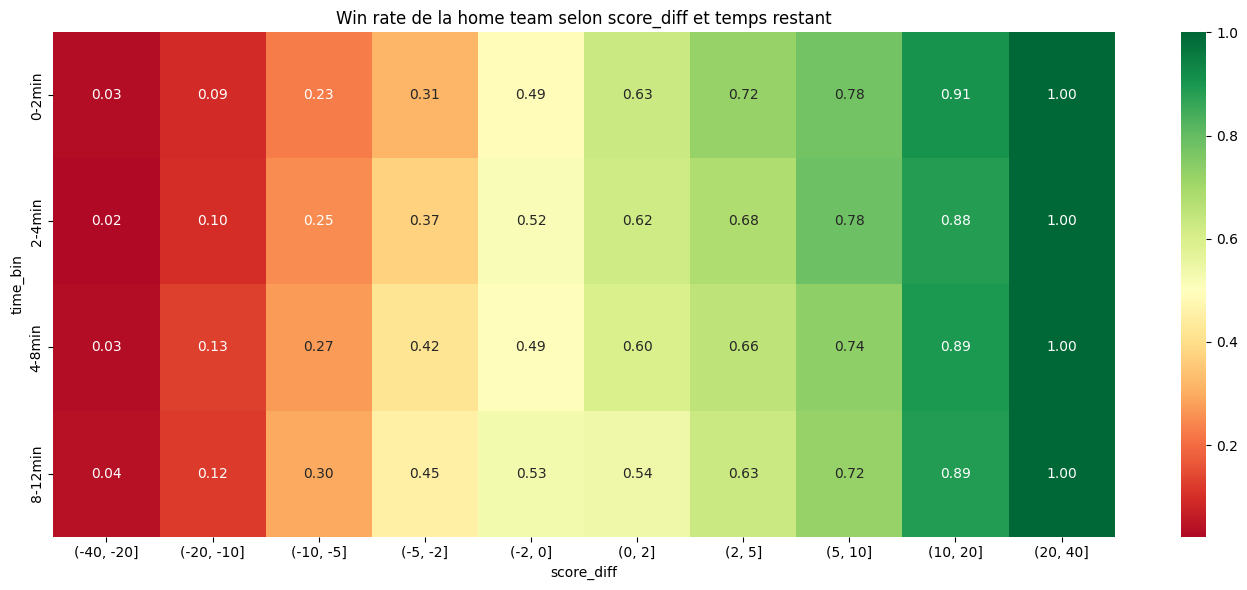

In [108]:
# Discrétiser le temps en tranches de 2 minutes
big_training_df['time_bin'] = pd.cut(big_training_df['time_remaining'], 
                         bins=[0,120,240,480,720,1080,1440,1800,2160,2880],
                         labels=['0-2min','2-4min','4-8min','8-12min',
                                 'Q3 fin','Q3 début','Q2','Q1 fin','Q1 début'])

pivot = big_training_df.groupby(['time_bin', pd.cut(big_training_df['score_diff'], 
                    bins=[-40,-20,-10,-5,-2,0,2,5,10,20,40])])['home_win'].mean().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5)
plt.title('Win rate de la home team selon score_diff et temps restant')
plt.tight_layout()

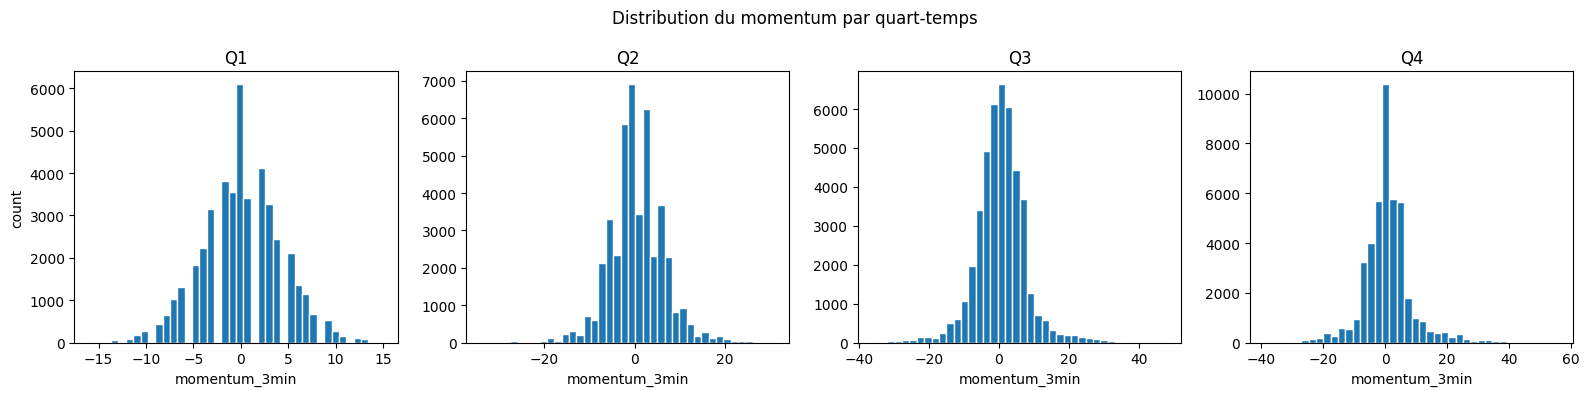

In [109]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, q in enumerate([1, 2, 3, 4]):
    data = big_training_df[big_training_df['quarter'] == q]['momentum_3min']
    axes[i].hist(data, bins=40, edgecolor='white')
    axes[i].set_title(f'Q{q}')
    axes[i].set_xlabel('momentum_3min')
axes[0].set_ylabel('count')
plt.suptitle('Distribution du momentum par quart-temps')
plt.tight_layout()

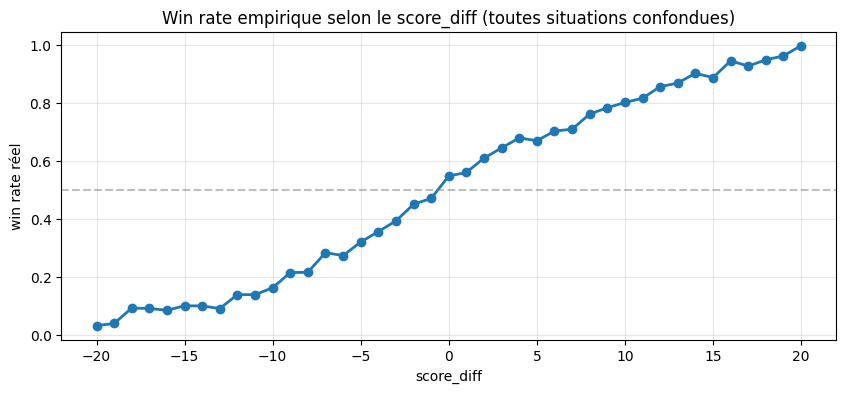

In [110]:
# Est-ce que score_diff seul est déjà un bon prédicteur ?
big_training_df['score_diff_clipped'] = big_training_df['score_diff'].clip(-20, 20)
calib = big_training_df.groupby('score_diff_clipped')['home_win'].mean()

plt.figure(figsize=(10, 4))
plt.plot(calib.index, calib.values, marker='o', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('score_diff')
plt.ylabel('win rate réel')
plt.title('Win rate empirique selon le score_diff (toutes situations confondues)')
plt.grid(alpha=0.3)